Chapter 4: Implementing a GPT model from Scratch To Generate Text

In [16]:
from importlib.metadata import version
print("matplotlib version", version ("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))



matplotlib version 3.10.0
torch version: 2.11.0+cpu
tiktoken version: 0.13.0


In this chapter ,we implement  a GPT-like LLM architecture

In [17]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [18]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

thats it for  today  , lets see it tommarow

In [19]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

batch =[]

txt1 = "Every effort moves you"
txt2 = "Every day holds a"
# txt1 ="After every Sunset Their is  "
# txt2="Tomorrow always brings another chance"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch , dim =0)
print(batch)



tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [20]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:" , logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


&nbsp;
## 4.2 Normalizing activations with layer normalization


Let's see how layer normalization works by passing a small input sample through a simple neural network layer:

In [21]:
torch.manual_seed(123)
batch_example =  torch.randn(2,5)

layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out= layer(batch_example)
print(out)


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [22]:
mean = out.mean(dim=-1 ,  keepdim =True)
var = out.var(dim =-1 , keepdim = True)
print(mean )
print(var)

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [23]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [24]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [25]:
class LayerNorm(nn.Module):
  def __init__(self , emb_dim):
    super().__init__()
    self.eps =1e-5
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.shift= nn.Parameter(torch.zeros(emb_dim))

  def forward(self , x):
    mean = x.mean(dim=-1 , keepdim=True)
    var = x.var(dim=-1 , keepdim = True , unbiased = False)
    norm_x = (x-mean)/torch.sqrt(var+self.eps)
    return self.scale*norm_x + self.shift




In [26]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [27]:
mean - out_ln.mean(dim=-1,  keepdim=True)
var= out_ln.var(dim=-1 , unbiased =False , keepdim = True)
print("Mean:\n", mean)
print("Variance:\n", var)


Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


&nbsp;
## 4.3 Implementing a feed forward network with GELU activations

In deep learning, ReLU (Rectified Linear Unit) activation functions are commonly used due to their simplicity and effectiveness in various neural network architectures
In LLMs, various other types of activation functions are used beyond the traditional ReLU; two notable examples are GELU (Gaussian Error Linear Unit) and SwiGLU (Swish-Gated Linear Unit)m




In practice, it's common to implement a computationally cheaper approximation:  GELU(x)≈0.5⋅x⋅(1+tanh[2π−−√⋅(x+0.044715⋅x3)])  (the original GPT-2 model was also trained with this approximation)


In [28]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self , x):
    return 0.5* x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

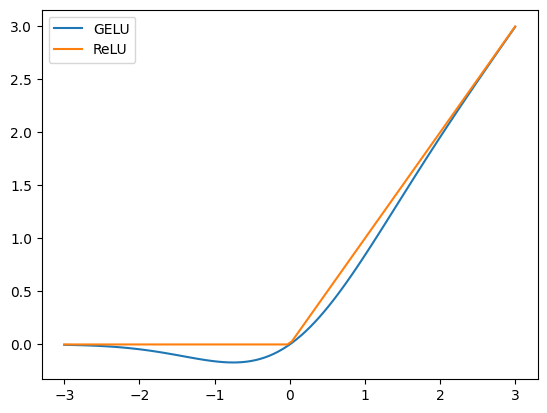

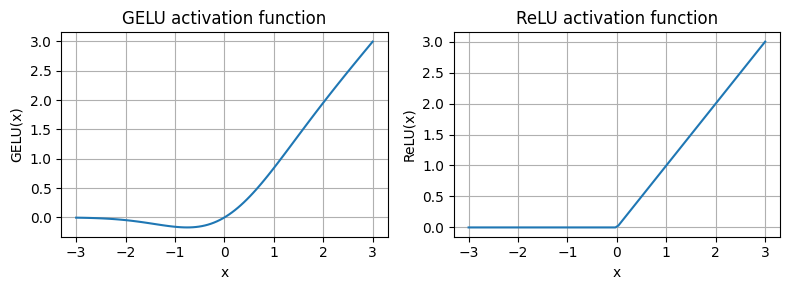

In [29]:
import matplotlib.pyplot as plt
gelu, relu = GELU() , nn.ReLU()

#Some sample data

x=torch.linspace(-3,3,100)
y_gelu = gelu(x)
y_relu = relu(x)

plt.plot(x.numpy(), y_gelu.numpy(), label='GELU')
plt.plot(x.numpy(), y_relu.numpy(), label='ReLU')
plt.legend()

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [31]:
ffn =FeedForward(GPT_CONFIG_124M)
#input shape : [batch size , numtoken , emb_size]
x= torch.rand(2,3,768)
out= ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


![image.png](
  
)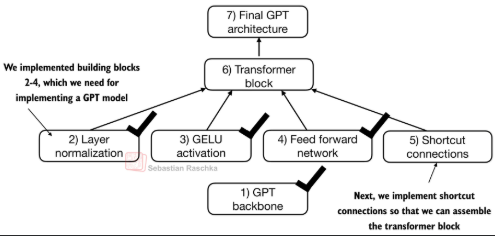

&nbsp;
## 4.4 Adding shortcut connections

shortcut connection  also called skip or residual connections

Originally, shortcut connections were proposed in deep networks for computer vision (residual networks) to mitigate vanishing gradient problems
A shortcut connection creates an alternative shorter path for the gradient to flow through the network

This is achieved by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between





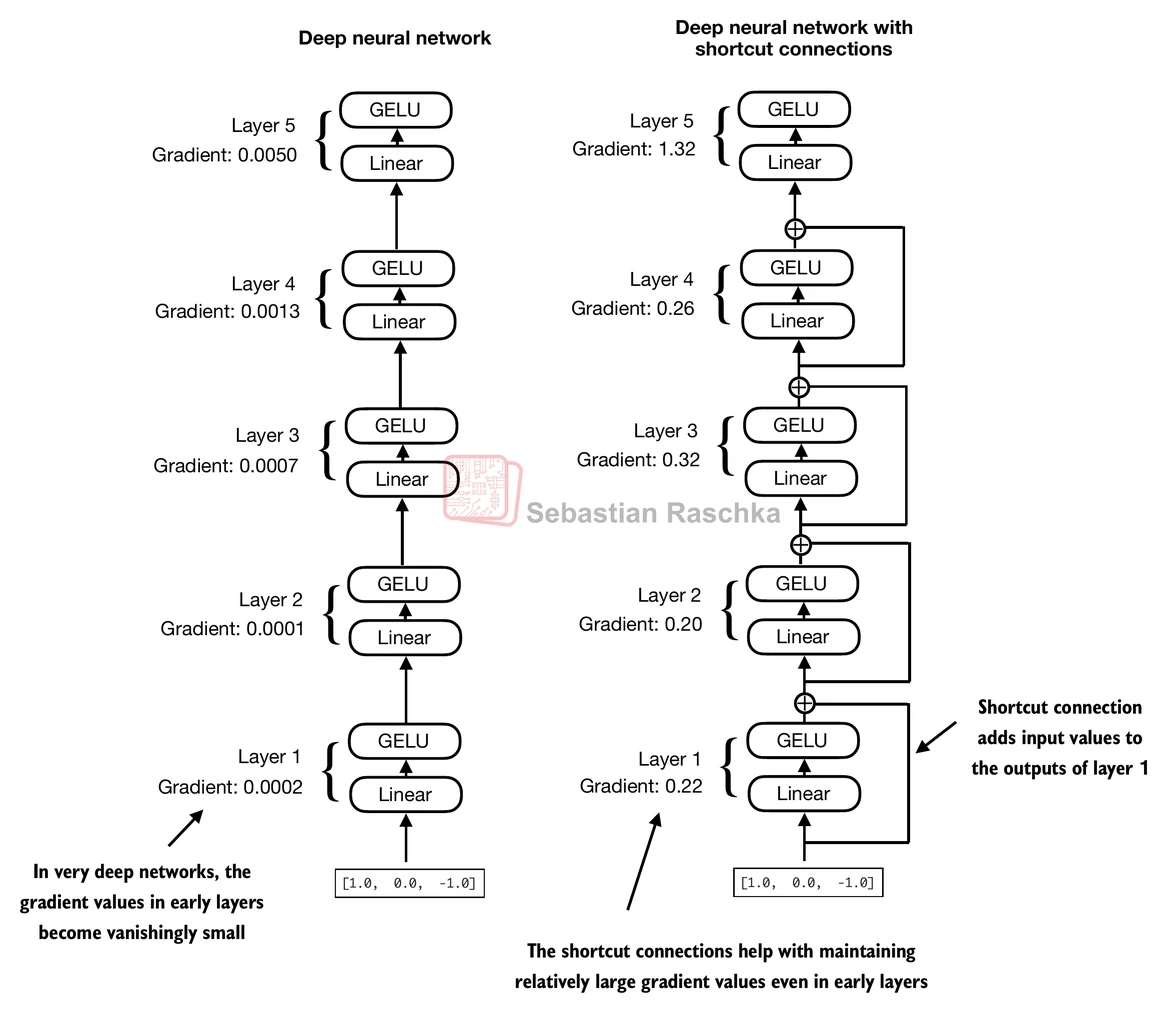

In [32]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

Let's print the gradient values first without shortcut connections:

In [33]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


Let's print the gradient values first without shortcut connections:


In [34]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


&nbsp;
## 4.5 Connecting attention and linear layers in a transformer block

- In this section, we now combine the previous concepts into a so-called transformer block
- A transformer block combines the causal multi-head attention module from the previous chapter with the linear layers, the feed forward neural network we implemented in an earlier section
` - In addition, the transformer block also uses dropout and shortcut connections

In [35]:
!git clone https://github.com/arjjunSharma/MyOwnLLM.git

fatal: destination path 'MyOwnLLM' already exists and is not an empty directory.


In [36]:
!pwd
!ls

/content
MyOwnLLM  sample_data


In [37]:
!jupyter nbconvert --to python /content/MyOwnLLM/ch03/ch03main.ipynb

[NbConvertApp] Converting notebook /content/MyOwnLLM/ch03/ch03main.ipynb to python
[NbConvertApp] Writing 18990 bytes to /content/MyOwnLLM/ch03/ch03main.py


In [38]:
!ls /content/MyOwnLLM/ch03

ch03main.ipynb	ch03main.py  __pycache__


In [39]:
import sys
sys.path.append("/content/MyOwnLLM/ch03")

import ch03main

In [40]:



class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x